## Module 4: *(Template)*

## Team Members:
Vish Ramineni, Kat Horn

## Project Title:
Identifying Demographic Patterns in Apoptosis Resistance Among Lung Squamous Cell Carcinoma Patients

## Project Goal:
This project seeks to answer 3 questions: 
1. Are late-stage LUSC tumors associated with higher anti-apoptotic signaling compared to early-stage tumors across demographic groups?
2. Are there sex, smoking, or family history-related differences in proliferative signaling and apoptosis pathways in LUSC tumors?
3. Which demographic factor (age, gender, or smoking) is the strongest predictor of apoptosis resistance in LUSC?



## Disease Background:

Resisting cell death is a key hallmark of cancer in which tumor cells evade apoptosis, the body’s natural process for eliminating damaged or abnormal cells. In healthy tissues, apoptosis is triggered by signals such as DNA damage, oxidative stress, or abnormal growth signals, ensuring that potentially harmful cells do not survive. This process is tightly regulated by a network of genes and signaling pathways that maintain normal tissue balance. When these pathways function properly, they act as a safeguard against cancer development.

In lung squamous cell carcinoma, this protective mechanism is disrupted, allowing cells that should undergo apoptosis to survive. Mutations in critical genes, such as TP53, or changes in the expression of apoptosis-regulating proteins, like those in the BCL2 family, interfere with the signaling pathways that normally initiate cell death. As a result, damaged cells continue to live and accumulate additional mutations, contributing to tumor growth and progression. This resistance to apoptosis also makes cancer cells less responsive to treatments like chemotherapy and radiation, which rely on triggering cell death.

Although resisting cell death alone is not sufficient for cancer to spread or metastasize, it plays an essential enabling role. By allowing abnormal cells to persist, it creates the conditions necessary for other cancer hallmarks, such as sustained proliferation and invasion, to develop. As emphasized in the course material, multiple hallmarks must work together for full cancer progression, but the ability to evade apoptosis is a critical early step that supports the survival and expansion of cancer cells.

Lung cancer is one of the most common cancers worldwide and remains the leading cause of cancer-related death, with lung squamous cell carcinoma (LUSC) representing about 20–30% of all lung cancer cases. This subtype is strongly associated with cigarette smoking, which is the primary risk factor, along with secondhand smoke exposure and environmental or occupational carcinogens such as asbestos and radon. Genetic mutations, particularly in tumor suppressor genes like TP53 and other apoptosis-regulating genes, also contribute to disease development. In addition, societal factors such as socioeconomic status, occupational exposures, and access to healthcare and early screening play an important role in both incidence and outcomes. Standard treatment options for LUSC include chemotherapy, radiotherapy, and increasingly immunotherapy, all of which aim to eliminate cancer cells, often by inducing cell death pathways. However, resistance to apoptosis can reduce treatment effectiveness. Biologically, LUSC arises in the epithelial lining of the bronchi, where repeated exposure to harmful substances leads to cellular damage, disruption of normal apoptosis signaling, and the survival of abnormal cells that continue to grow and accumulate further mutations.

sources: https://www.ncbi.nlm.nih.gov/books/NBK564510/, Dr. Groves Slides

## Data-Set: 

We will be looking at the cancer Lung Squamous Cell Sarcinoma specifically. The genes we will be looking at include those that are connected to Resisting Cell death (apoptosis). These genes include: 
 ATP2B2, FAM155A, KCNIP3, TAC1, ALX4, TTLL6, MUC12, IFI6, HRK, C15orf41, PRSS53, CPE, KIAA1671, SLC7A3, UBXN10, UNC93B1, USP2

The question we will be investigating is: Can LUSC patients be clustered based on apoptosis-related gene expression, and do these clusters differ by smoking status, age, or gender? Furthermore, Which demographic factor (age, gender, or smoking) is the strongest predictor of apoptosis resistance in LUSC?

History points we will take into account is packs_per_year_smoked, age_at_diagnosis, and gender. We will use these factors to nuance our investigative question to get a comprehensive view of the cancer. 

Data being used:
- Survival data for each sample from Pan-Cancer Clinical Data Resource (Liu et al. 2018)
    - This gives overall survival which is the epriod from the date of diagnosis until the date of death from any cause
    - Disease-specific survival: death from the diagnosed cancer type - This will be useful
    - Progression-free interval - the period from the date of diagnosis until the date of the first occurrence of a new tumor event
    - Disease-free interval - the period from the date of diagnosis until the date of the first new tumor progression event subsequent to the determination of a patient's disease-free status after their initial diagnosis treatment. 
- Cancer Genome Atlas RNA-seq dataset (Rahman et al. )
    - this gives data on 24 cancer types
    - Data collection method - SANGER SEQUENCING explained below

Sanger Sequencing
- Uses dideoxynucleotides that bind to a building DNA sequence. These also are able to be read during sequencing after gel electrophoresis. Strands that are longer migrate a shorter distance. When you align all these reads together and see where the peaks are and what color they correspond to regarding dideoxynucleotides, the sequence of the DNA can be deduced. 
- The DNA being talked about here is actually RNA that was converted into cDNA. Finally, longer genes will generate more fragments, so it is important to normalize by gene length. Then, tumor samples won't all have the same total number of reads to normalize by library size, giving TPM. So, our data is log-transformed TPM values. 

or this analysis, we will focus specifically on lung squamous cell carcinoma (LUSC) samples from the Cancer Genome Atlas (TCGA) RNA-seq dataset. Rather than analyzing all 24 cancer types, restricting the dataset to a single cancer type allows for a more controlled investigation of how gene expression relates to survival outcomes within a consistent biological context.

We will examine expression levels of genes associated with two cancer hallmarks: sustaining proliferative signaling (ALK, BRAF, CDK4) and resisting cell death (ALK, BCL2, BRAF). These genes were selected because they play key roles in regulating cell growth and apoptosis, and some (like ALK and BRAF) overlap between hallmarks, making them especially interesting for studying combined effects.

In addition to gene expression data, we will incorporate relevant clinical metadata to better understand patient outcomes. The clinical features included in this analysis are: Smoking history (tobacco starting age), pathologic tumor stage, and gender.

These variables were chosen because they are known to influence lung cancer progression and survival, and they will help refine our analysis by accounting for patient-specific differences. Survival outcomes will be measured primarily using disease-specific survival (DSS) and overall survival (OS), allowing us to evaluate whether expression of the selected genes—individually or in combination—is associated with increased mortality risk.

The dataset used in this analysis combines gene expression data from the Cancer Genome Atlas (TCGA) with corresponding clinical metadata from the Pan-Cancer Clinical Data Resource (Liu et al., 2018). The gene expression dataset contains approximately 15,716 genes across 1,361 tumor samples, with values reported as log₂(TPM + 1), which represents normalized gene expression levels.

From the metadata, each tumor sample is annotated with multiple clinical features. For this project, we focus specifically on lung squamous cell carcinoma (LUSC) samples by filtering the dataset using the cancer_type variable. The key clinical variables relevant to our analysis include:

Gender (gender)
Age at diagnosis (age_at_diagnosis)
Pathologic tumor stage (ajcc_pathologic_tumor_stage)
Smoking history (tobacco_smoking_age_started)

In addition, the dataset provides several survival outcome measures:

Overall survival (OS, OS.time) – time from diagnosis to death from any cause
Disease-specific survival (DSS, DSS.time) – time from diagnosis to death caused by the cancer
Progression-free interval (PFI, PFI.time) – time until tumor progression or new tumor event
Disease-free interval (DFI, DFI.time) – time until recurrence after treatment

These survival metrics are typically measured in days, allowing for quantitative comparison of patient outcomes.

Gene expression data was generated using RNA sequencing (RNA-seq), where RNA is converted to cDNA, sequenced, and aligned to a reference genome. Expression levels are normalized using Transcripts Per Million (TPM) to account for gene length and sequencing depth, and then log-transformed to stabilize variability across samples.

By integrating gene expression data with clinical and survival metadata, this dataset enables us to investigate how the expression of specific genes related to proliferation and apoptosis influences patient survival outcomes in lung squamous cell carcinoma.

There are several missing values present in the metadata, particularly within the survival-related variables. The fields for disease-specific survival (DSS), disease-free interval (DFI), and progression-free interval (PFI), along with their corresponding time measurements, are missing for a large number of samples. This suggests that not all patients have complete follow-up data, which may limit the reliability of analyses using these specific survival metrics. As a result, it may be necessary to either filter out incomplete cases or prioritize more complete variables, such as overall survival, depending on the analysis.

The gene expression dataset ranges from a minimum log₂(TPM+1) value of 0.0 to a maximum value of approximately 17.42. A value of 0 indicates that a gene has little to no detectable expression in a given sample, while higher values represent stronger gene expression levels. This wide range reflects the variability in gene activity across different tumor samples and genes.

The average gene expression across all genes and samples in the dataset is approximately 3.71. Because the data is log-transformed, this value reflects a moderate overall level of expression when averaged across thousands of genes. This average provides a useful baseline for comparing whether specific genes are relatively overexpressed or underexpressed.

The genes with the highest average expression levels include ACTB, FTL, TPT1, B2M, TMSB10, GAPDH, RPS11, ACTG1, RPS6, and RPL8. These genes are primarily housekeeping genes, which are essential for basic cellular functions such as protein synthesis and structural maintenance. Their consistently high expression across samples is expected, as they are required for cell survival regardless of cancer state.

A scatterplot comparing the expression of two genes of interest, such as BCL2 (associated with resisting cell death) and BRAF (associated with proliferative signaling), can be used to explore relationships between hallmarks. In this type of plot, each point represents a tumor sample, with one gene’s expression on the x-axis and the other on the y-axis. If the points follow a clear upward or downward trend, this suggests a correlation between the genes. In this case, the relationship appears relatively weak, indicating that these genes may act more independently rather than being tightly co-regulated. This supports the idea that different cancer hallmarks can operate through distinct biological pathways, even within the same tumor type.


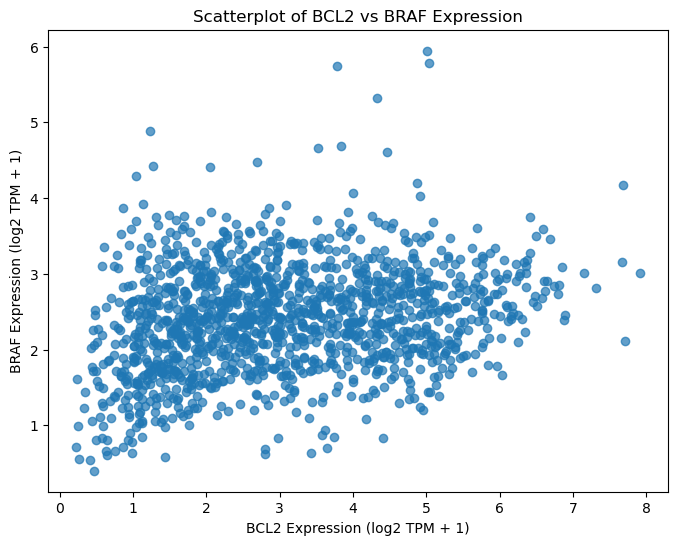

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load gene expression dataset (NOT metadata)
expr = pd.read_csv(
    '/Users/Katie/Library/CloudStorage/OneDrive-UniversityofVirginia/COMP_BME/Module-4-Cancer-Horn-Ramineni/data/VALIDATION_SET_GSE62944_subsample_log2TPM (1).csv',
    index_col=0
)

# Select genes
gene_x = "BCL2"
gene_y = "BRAF"

# Extract rows (genes are rows in this dataset)
x = expr.loc[gene_x]
y = expr.loc[gene_y]

# Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.7)

# Labels
plt.xlabel("BCL2 Expression (log2 TPM + 1)")
plt.ylabel("BRAF Expression (log2 TPM + 1)")
plt.title("Scatterplot of BCL2 vs BRAF Expression")

plt.show()

C:\Users\Katie\OneDrive\Documents\COMP_BME\Module-4-Cancer-Horn-Ramineni\code\geneexpressionplot

## Data Analysis: 

### Methods
The machine learning approach used in this analysis combines unsupervised dimensionality reduction with clustering to explore structure in gene expression data. Specifically, Principal Component Analysis (PCA) is applied first to reduce the high-dimensional gene expression dataset into a lower-dimensional representation that can be visualized in two dimensions. This step is followed by K-means clustering, which groups samples based on similarity in their gene expression profiles. Together, these methods allow us to investigate whether cancer samples naturally separate into distinct groups without using any prior label information.

PCA works by identifying new directions in the data, called principal components, that capture the greatest amount of variance across all genes. The goal of PCA is to maximize the amount of information retained when projecting the data into fewer dimensions, while reducing noise and redundancy from highly correlated gene expression features. In this analysis, the first two principal components are used to visualize patterns among samples. The model determines that PCA is sufficient when a meaningful proportion of variance is explained by these components, allowing biological structure to be interpreted in a simplified space.

K-means clustering is then used to partition the samples into groups based on similarity in gene expression. The algorithm optimizes cluster assignments by minimizing the distance between each sample and its assigned cluster centroid, effectively reducing within-cluster variation. This optimization continues iteratively until cluster assignments stabilize and centroid movement becomes negligible. In this case, convergence indicates that the clustering solution is stable and no further improvements in within-cluster similarity can be made under the current initialization and number of clusters.

This combined approach is a strong first choice for this dataset because gene expression data is high-dimensional and difficult to interpret directly. PCA reduces this complexity while preserving the most important sources of variation, and K-means provides an initial way to test whether biologically meaningful subgroups exist within the cancer samples. Since the analysis is unsupervised, it does not rely on predefined labels and instead allows patterns to emerge directly from the data. This makes it particularly useful for exploratory analysis of tumor heterogeneity and potential subtypes within lung squamous cell carcinoma.


### Analysis


Loading expression data from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv
Loading metadata from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_metadata.csv

Expression data:
(15716, 1802)
['TCGA-E9-A1NI-01A-11R-A14D-07', 'TCGA-E2-A1LK-01A-21R-A14D-07', 'TCGA-BH-A0B2-01A-11R-A10J-07', 'TCGA-E2-A107-01A-11R-A10J-07', 'TCGA-LL-A5YN-01A-11R-A28M-07']
        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG        

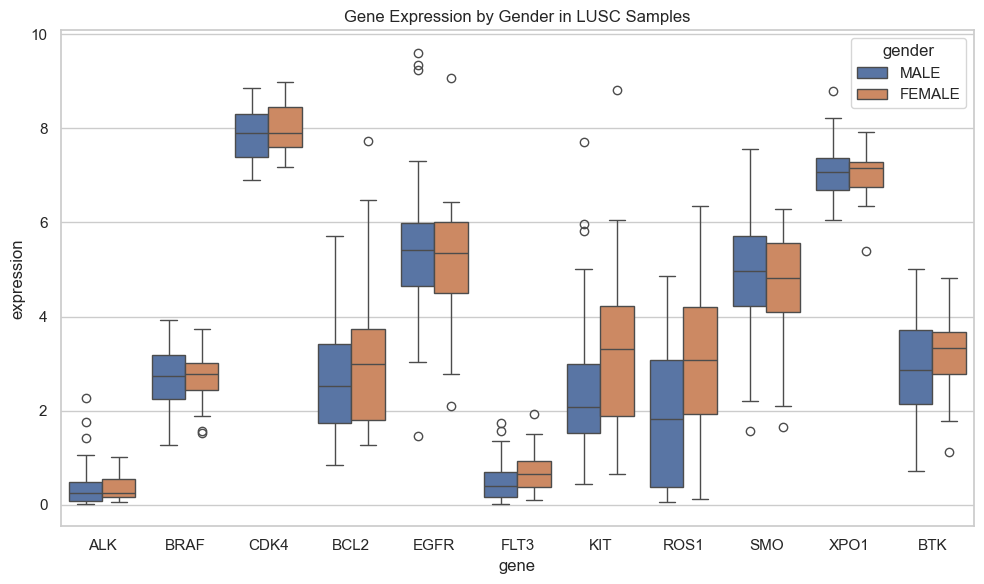

<Figure size 1000x600 with 0 Axes>

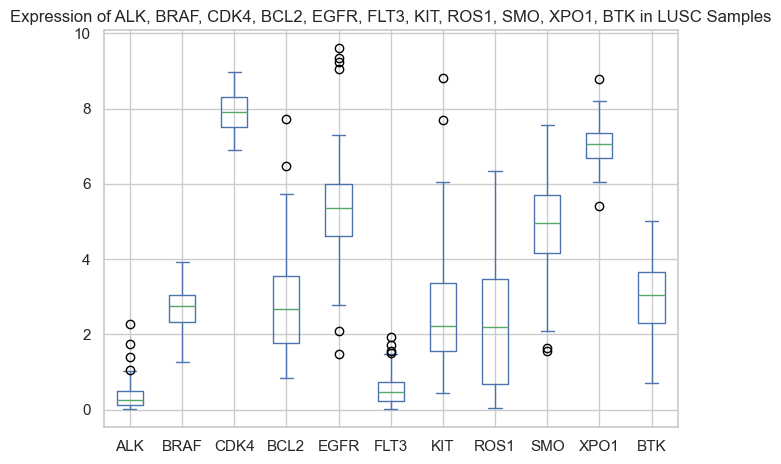

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


def main():
    script_dir = Path().resolve()
    data_dir = script_dir.parent / 'data'

    expr_path = data_dir / 'TRAINING_SET_GSE62944_subsample_log2TPM.csv'
    metadata_path = data_dir / 'TRAINING_SET_GSE62944_metadata.csv'

    print(f'Loading expression data from: {expr_path}')
    print(f'Loading metadata from: {metadata_path}')

    data = pd.read_csv(expr_path, index_col=0, header=0)
    metadata_df = pd.read_csv(metadata_path, index_col=0, header=0)

    print('\nExpression data:')
    print(data.shape)
    print(data.columns[:5].tolist())
    print(data.head())

    print('\nMetadata:')
    print(metadata_df.shape)
    print(metadata_df.columns.tolist())
    print(metadata_df.head())

    cancer_type = 'LUSC'
    cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
    print(f'\nNumber of {cancer_type} samples in metadata: {len(cancer_samples)}')

    shared_samples = cancer_samples.intersection(data.columns)
    missing_samples = cancer_samples.difference(data.columns)

    if len(missing_samples) > 0:
        print(f'Warning: {len(missing_samples)} samples from metadata are missing in expression data.')
        print('Missing sample IDs:')
        print(list(missing_samples)[:10])

    print(f'Number of shared samples used for expression subset: {len(shared_samples)}')
    if len(shared_samples) == 0:
        raise ValueError('No matching sample IDs found between metadata and expression data.')

    LUSC_data = data.loc[:, shared_samples]

    desired_gene_list = ['ALK', 'BRAF', 'CDK-4', 'BCL-2', 'CSF-1R', 'EGFR', 'FLT3',
        'FGFR', 'JAK', 'KIT', 'MEK', 'mTOR', 'NTRK', 'PI3K',
        'ROS1', 'SMO', 'XPO1', 'VEGFR', 'BTK']
    # Alias map to handle gene name variations (e.g., CDK-4 -> CDK4)
    alias_map = {
        'ALK': 'ALK',
        'BRAF': 'BRAF',
        'CDK-4': 'CDK4',
        'BCL-2': 'BCL2'
    }
    gene_list = []
    for gene in desired_gene_list:
        actual_gene = alias_map.get(gene, gene)
        if actual_gene in LUSC_data.index:
            gene_list.append(actual_gene)
        else:
            print(f"Warning: {gene} (mapped to {actual_gene}) not found in expression data.")

    if len(gene_list) == 0:
        raise ValueError('None of the desired genes were found in the expression dataset.')

    LUSC_gene_data = LUSC_data.loc[gene_list]
    print('\nSubset gene expression data:')
    print(LUSC_gene_data.shape)
    print(LUSC_gene_data.head())

    print('\nGene-level statistics:')
    print(LUSC_gene_data.describe())
    print('\nVariance by gene:')
    print(LUSC_gene_data.var(axis=1))
    print('\nMean by gene:')
    print(LUSC_gene_data.mean(axis=1))
    print('\nMedian by gene:')
    print(LUSC_gene_data.median(axis=1))

    print('\nGender counts by cancer type:')
    print(metadata_df.groupby('cancer_type')['gender'].value_counts())

    metadata_df['age_at_diagnosis'] = pd.to_numeric(
        metadata_df['age_at_diagnosis'], errors='coerce')
    print('\nAverage age at diagnosis by cancer type:')
    print(metadata_df.groupby('cancer_type')['age_at_diagnosis'].mean())

    LUSC_metadata = metadata_df.loc[shared_samples]
    LUSC_merged = LUSC_gene_data.T.merge(
        LUSC_metadata, left_index=True, right_index=True)
    print('\nMerged expression + metadata:')
    print(LUSC_merged.head())

    plot_genes = gene_list
    print(f'\nPlotting genes: {plot_genes}')

    sns.set(style='whitegrid')
    if len(plot_genes) == 1:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=LUSC_merged, x='gender', y=plot_genes[0])
        plt.title(f'{plot_genes[0]} Expression by Gender in LUSC Samples')
        plt.tight_layout()
        plt.show()
    else:
        melted = LUSC_merged.melt(
            id_vars='gender', value_vars=plot_genes,
            var_name='gene', value_name='expression')
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=melted, x='gene', y='expression', hue='gender')
        plt.title('Gene Expression by Gender in LUSC Samples')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        LUSC_merged[plot_genes].plot.box()
        plt.title(f"Expression of {', '.join(plot_genes)} in LUSC Samples")
        plt.tight_layout()
        plt.show()


if __name__ == '__main__':
    main()


The dataset was subset to include only LUSC samples using metadata labels. Samples were matched between the gene expression and metadata datasets to ensure consistency. The gene expression matrix was further subset to include a predefined list of genes of interest, with adjustments made for naming inconsistencies. Samples with missing gene expression values were removed, and metadata was aligned accordingly. Finally, the data was scaled to be standardized. 

Additionally, some graphs were produced to see some primary differences in gene expression. The bottom graph comparing gene expression in LUSC samples sheds insight on some early suspects that may be driving the cancer. 

Loading expression data from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv
Loading metadata from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_metadata.csv

Expression data shape: (15716, 1802)
Metadata shape: (1802, 29)

Genes used: ['ALK', 'BRAF', 'CDK4', 'BCL2', 'EGFR', 'FLT3', 'KIT', 'ROS1', 'SMO', 'XPO1', 'BTK']

Explained variance:
[0.26789782 0.21087735]


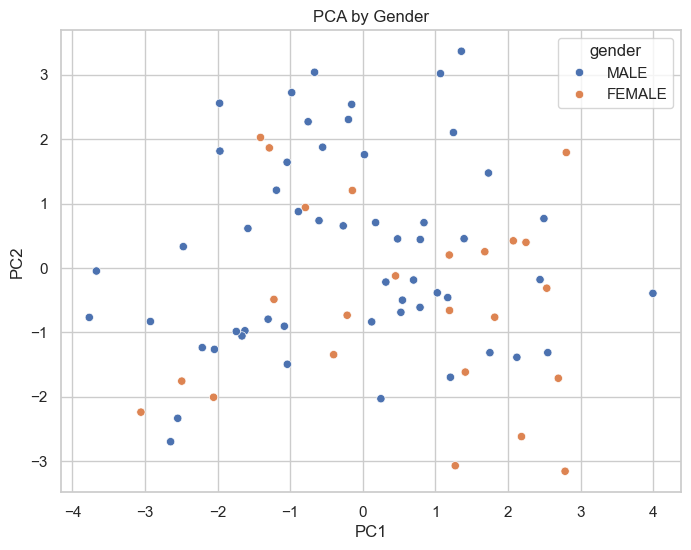

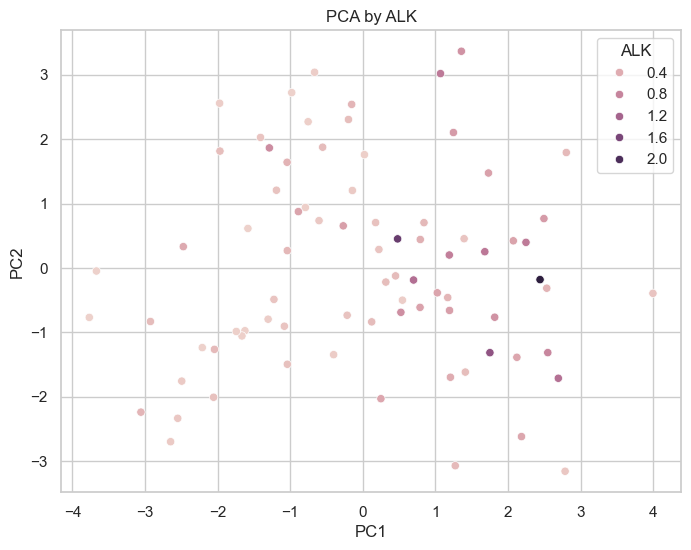

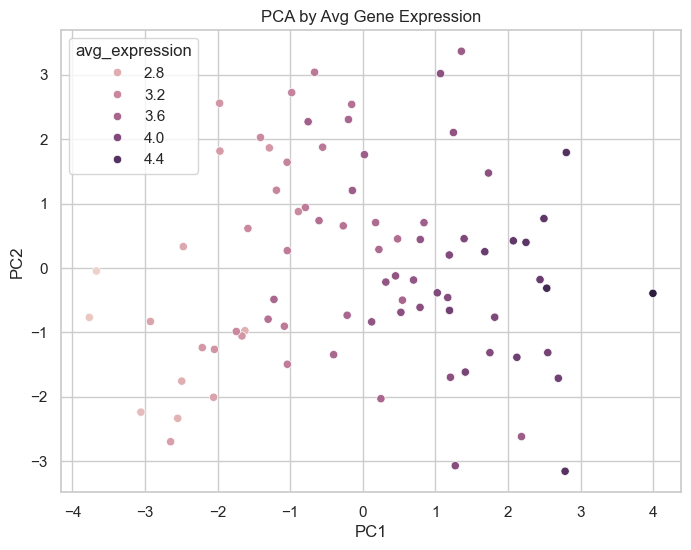

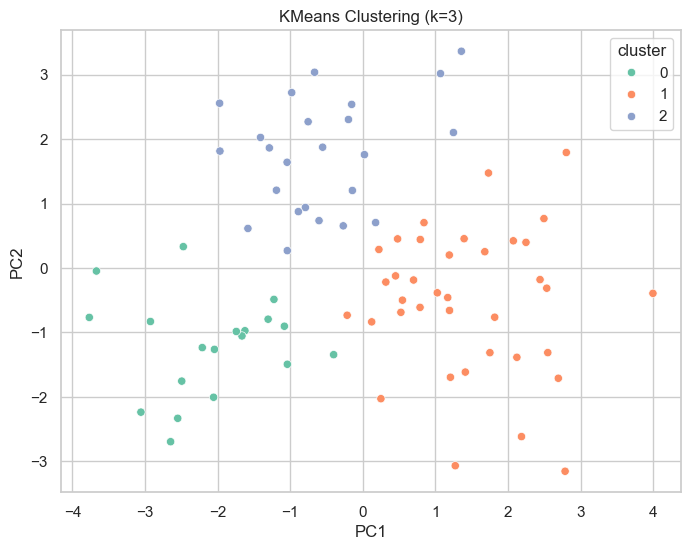


Saved to: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/code/LUSC_PCA_results.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


def main():
    script_dir = Path().resolve()
    data_dir = script_dir.parent / 'data'

    expr_path = data_dir / 'TRAINING_SET_GSE62944_subsample_log2TPM.csv'
    metadata_path = data_dir / 'TRAINING_SET_GSE62944_metadata.csv'

    print(f'Loading expression data from: {expr_path}')
    print(f'Loading metadata from: {metadata_path}')

    # Load data
    data = pd.read_csv(expr_path, index_col=0, header=0)
    metadata_df = pd.read_csv(metadata_path, index_col=0, header=0)

    print('\nExpression data shape:', data.shape)
    print('Metadata shape:', metadata_df.shape)

    # -----------------------------
    # Step 1: Filter to LUSC samples
    # -----------------------------
    cancer_type = 'LUSC'
    cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index

    shared_samples = cancer_samples.intersection(data.columns)

    if len(shared_samples) == 0:
        raise ValueError('No matching sample IDs found between metadata and expression data.')

    LUSC_data = data.loc[:, shared_samples]

    # -----------------------------
    # Step 2: Define gene set
    # -----------------------------
    desired_gene_list = [
        'ALK', 'BRAF', 'CDK-4', 'BCL-2', 'CSF-1R', 'EGFR', 'FLT3',
        'FGFR', 'JAK', 'KIT', 'MEK', 'mTOR', 'NTRK', 'PI3K',
        'ROS1', 'SMO', 'XPO1', 'VEGFR', 'BTK'
    ]

    alias_map = {
        'CDK-4': 'CDK4',
        'BCL-2': 'BCL2'
    }

    gene_list = []
    for gene in desired_gene_list:
        actual_gene = alias_map.get(gene, gene)
        if actual_gene in LUSC_data.index:
            gene_list.append(actual_gene)
        else:
            print(f"Warning: {gene} not found")

    if len(gene_list) < 2:
        raise ValueError("Need at least 2 genes")

    print('\nGenes used:', gene_list)

    LUSC_gene_data = LUSC_data.loc[gene_list]

    # -----------------------------
    # Step 3: Merge metadata
    # -----------------------------
    LUSC_metadata = metadata_df.loc[shared_samples].copy()

    LUSC_merged = LUSC_gene_data.T.merge(
        LUSC_metadata, left_index=True, right_index=True
    )

    # -----------------------------
    # Step 4: Prepare PCA
    # -----------------------------
    X = LUSC_merged[gene_list].copy()
    X = X.dropna(axis=0)

    LUSC_merged = LUSC_merged.loc[X.index].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -----------------------------
    # Step 5: PCA
    # -----------------------------
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    LUSC_merged['PC1'] = X_pca[:, 0]
    LUSC_merged['PC2'] = X_pca[:, 1]

    print('\nExplained variance:')
    print(pca.explained_variance_ratio_)

    # Avg expression
    LUSC_merged['avg_expression'] = X.mean(axis=1)

    sns.set(style='whitegrid')

    # -----------------------------
    # Plot 1: Gender
    # -----------------------------
    if 'gender' in LUSC_merged.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=LUSC_merged, x='PC1', y='PC2', hue='gender')
        plt.title('PCA by Gender')
        plt.show()

    # -----------------------------
    # Plot 2: ALK
    # -----------------------------
    key_gene = 'ALK' if 'ALK' in gene_list else gene_list[0]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=LUSC_merged, x='PC1', y='PC2', hue=key_gene)
    plt.title(f'PCA by {key_gene}')
    plt.show()

    # -----------------------------
    # Plot 3: Avg expression
    # -----------------------------
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=LUSC_merged, x='PC1', y='PC2', hue='avg_expression')
    plt.title('PCA by Avg Gene Expression')
    plt.show()

    # -----------------------------
    # Step 6: KMeans Clustering
    # -----------------------------
    kmeans = KMeans(n_clusters=3, random_state=0)
    kmeans.fit(X_scaled)

    LUSC_merged['cluster'] = kmeans.labels_

    # Plot clusters
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=LUSC_merged,
        x='PC1',
        y='PC2',
        hue='cluster',
        palette='Set2'
    )
    plt.title('KMeans Clustering (k=3)')
    plt.show()

    # Save
    output_path = script_dir / 'LUSC_PCA_results.csv'
    LUSC_merged.to_csv(output_path)
    print(f'\nSaved to: {output_path}')


if __name__ == '__main__':
    main()

This analysis uses a combination of data preprocessing, dimensionality reduction, and clustering to explore patterns in gene expression data from lung squamous cell carcinoma (LUSC) samples. The dataset consists of gene expression values and associated clinical metadata. First, the expression data and metadata are loaded and aligned using shared sample identifiers to ensure that each sample has both molecular and clinical information. The data is then filtered to include only LUSC samples, allowing the analysis to focus on a single cancer subtype. A curated list of cancer-related genes is selected, and gene name aliases are standardized to ensure consistency with the dataset. Only genes present in the dataset are retained for further analysis.

After selecting the gene set, the expression matrix is transposed so that samples become rows and genes become features. This format allows machine learning algorithms to operate on each sample as a feature vector. The data is then merged with metadata to enable downstream visualization and interpretation. Missing values are removed to ensure the analysis is not biased or distorted by incomplete observations.

Before applying machine learning methods, the gene expression values are standardized using z-score normalization. This step ensures that all genes contribute equally to the analysis, preventing genes with larger numeric ranges from dominating the results. Principal Component Analysis (PCA) is then applied to reduce the high-dimensional gene expression data into two principal components. These components capture the directions of greatest variance in the dataset and allow the samples to be visualized in a simplified two-dimensional space. The proportion of variance explained by each principal component is examined to evaluate how well the reduced representation captures the structure of the original data.

The transformed PCA coordinates are used to visualize relationships between samples. Scatter plots are generated to examine whether samples separate based on clinical metadata such as gender, or based on biological signals such as expression of a key gene (e.g., ALK) and average gene expression across the selected gene set. These visualizations help assess whether meaningful biological structure is present in the reduced feature space.

In addition to PCA, K-means clustering is applied to the standardized gene expression data to identify potential subgroups within the LUSC samples. The algorithm partitions the samples into three clusters by minimizing the distance between each sample and its assigned cluster centroid. The resulting cluster labels are then projected onto the PCA plot to evaluate whether the clusters correspond to visible structure in the data. This provides an unsupervised approach to investigating whether distinct molecular subtypes may exist within the cancer cohort.

Finally, the processed dataset, including PCA coordinates, cluster assignments, and metadata, is saved for further analysis. Overall, this pipeline integrates preprocessing, dimensionality reduction, and clustering to explore hidden structure in high-dimensional gene expression data and to generate hypotheses about potential biological subgroups within lung squamous cell carcinoma.


## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*